# Chapter 2: Step 2 — Introduction to Machine Learning

**Course:** Supervised Machine Learning  
**Source:** *Mastering Machine Learning with Python in Six Steps* — Manohar Swamynathan (2019)  
**Book pages:** 65–143 (PDF pages 80–158)

---

## Welcome!

This notebook covers **Chapter 2** of the textbook. You will learn what machine learning is, how it relates to AI and data science, and how to use **NumPy**, **Pandas**, and **Matplotlib** — the core Python libraries for data analysis.

**How to use this notebook:**
1. Run cells **top to bottom** (Shift + Enter).
2. Read each markdown explanation **before** running the code below it.
3. All code listings from the book (Listings 2-1 through 2-49) are included with fixes for modern Python 3.


## Shared Setup

Run this cell first. It imports the libraries used throughout the chapter and creates helper data:
- `iris_df` — Iris flower measurements with book-style column names (`Sepal.Length`, etc.)
- `df_1` and `df_2` — employee tables used in join/merge examples (Listings 2-27–2-32)


In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from pathlib import Path

NOTEBOOK_DIR = Path('.').resolve()


def load_iris_df():
    """Load sklearn iris data as a DataFrame with book-style dotted column names."""
    iris = load_iris()
    cols = ['Sepal.Length', 'Sepal.Width', 'Petal.Length', 'Petal.Width']
    return pd.DataFrame(iris.data, columns=cols)


iris_df = load_iris_df()

# Employee DataFrames for join examples (Listings 2-27 through 2-32)
data_1 = {
    'emp_id': ['1', '2', '3', '4', '5'],
    'first_name': ['Jason', 'Andy', 'Allen', 'Alice', 'Amy'],
    'last_name': ['Larkin', 'Jacob', 'A', 'AA', 'Jackson'],
}
df_1 = pd.DataFrame(data_1, columns=['emp_id', 'first_name', 'last_name'])

data_2 = {
    'emp_id': ['4', '5', '6', '7'],
    'first_name': ['Brian', 'Shize', 'Kim', 'Jose'],
    'last_name': ['Alexander', 'Suma', 'Mike', 'G'],
}
df_2 = pd.DataFrame(data_2, columns=['emp_id', 'first_name', 'last_name'])

print('Setup complete.')
print('iris_df shape:', iris_df.shape)
print('df_1 rows:', len(df_1), '| df_2 rows:', len(df_2))


Setup complete.
iris_df shape: (150, 4)
df_1 rows: 5 | df_2 rows: 4


---

## What Is Machine Learning?

**Machine learning (ML)** is a subfield of computer science that evolved from pattern recognition and computational learning theory in **artificial intelligence (AI)**.

Key definitions from the book:
- **Arthur Samuel (1959):** *"Field of study that gives computers the ability to learn without being explicitly programmed."*
- **Broader view:** ML uses statistical methods to create programs that improve over time or detect patterns in massive data.

In short, ML is a collection of algorithms and techniques used to build computational systems that **learn from data** to make predictions and inferences.

### Common ML Applications
| Application | Example |
|---|---|
| Recommendation systems | YouTube video suggestions, Amazon product recommendations |
| Spam detection | E-mail providers filtering unsolicited messages |
| Prospect identification | Banks predicting which customers will convert |


## History and Evolution of AI

ML is a **subset of AI**. AI aims to replicate or surpass human intelligence in machines — to observe, read, learn, sense, and experience.

### The AI Process Loop (Figure 2-1)
1. **Observe** — Identify patterns using data
2. **Plan** — Find all possible solutions
3. **Optimize** — Find the optimal solution
4. **Action** — Execute the optimal solution
5. **Learn and Adapt** — If results are unexpected, adapt

The next cell draws Figure 2-1.


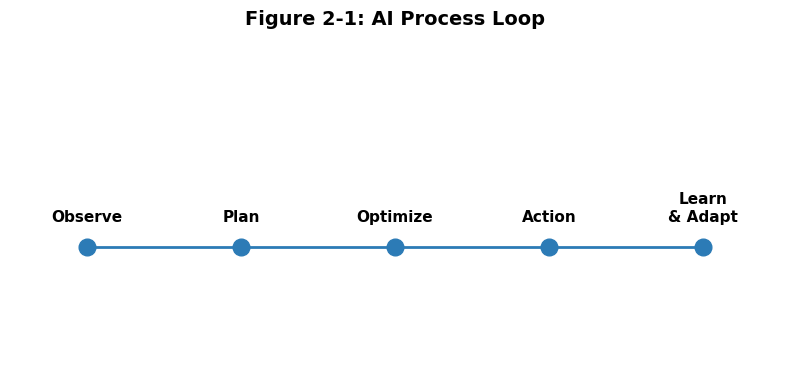

In [2]:
# Figure 2-1: AI process loop
fig, ax = plt.subplots(figsize=(8, 4))
steps = ['Observe', 'Plan', 'Optimize', 'Action', 'Learn\n& Adapt']
x = np.arange(len(steps))
ax.plot(x, np.zeros(len(steps)), 'o-', color='#2c7bb6', linewidth=2, markersize=12)
for i, label in enumerate(steps):
    ax.annotate(label, (i, 0), textcoords='offset points', xytext=(0, 18),
                ha='center', fontsize=11, fontweight='bold')
ax.set_xlim(-0.5, len(steps) - 0.5)
ax.set_ylim(-0.5, 0.8)
ax.axis('off')
ax.set_title('Figure 2-1: AI Process Loop', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Intelligent Agents and the Taxi Driver Example

An **intelligent agent** perceives its environment through sensors and acts through effectors (like humans with eyes, ears, hands, and legs).

**Automated taxi driver example (Table 2-1):**
| Component | Taxi Driver |
|---|---|
| Agent type | Taxi driver |
| Goals | Safe, legal, comfortable trip; maximize profits |
| Environment | Roads, traffic, signals, pedestrians, customers |
| Percepts | Speedometer, GPS, cameras, sonar, sensors |
| Actions | Steer, accelerate, brake, talk to passenger |

### The Turing Test (1950)
Alan Turing proposed an operational test of intelligence: a human should not be able to distinguish a machine from another human by their replies to questions.

To pass the Turing test, a computer needs capabilities in:
- Natural language processing
- Knowledge representation (expert systems)
- Automated reasoning
- **Machine learning**
- Computer vision
- Robotics
- Planning, scheduling, and optimization


### ANI, AGI, and ASI

| Level | Name | Description |
|---|---|---|
| **ANI** | Artificial Narrow Intelligence | Equals or exceeds humans at a **specific task** (e.g., IBM Watson) |
| **AGI** | Artificial General Intelligence | Applies intelligence to **any problem** in an area (e.g., self-driving cars) |
| **ASI** | Artificial Super Intelligence | Smarter than the best human brains in practically every field |


## Statistics vs. Data Science vs. Data Analytics

Several fields use data to learn and predict. They share methods but evolved with different histories and cultures:

- **Statistics** — Collection, analysis, interpretation, and presentation of data (origin: 18th century state administration)
- **Data mining / KDD** — Discovering patterns in large datasets (coined 1989)
- **Data analytics** — Inspecting, cleaning, and modeling data for decision making
- **Data science** — Interdisciplinary field extracting knowledge from structured and unstructured data

> **Note:** ML originated from AI. Data science **uses** ML as a tool; ML is not a branch of data science.

### Descriptive vs. Predictive Analytics (Figure 2-4)
1. **Descriptive** — *What happened?* (counts, averages, reports)
2. **Diagnostic** — *Why did it happen?* (drill-down, correlations)
3. **Predictive** — *What might happen?* (ML, forecasting)
4. **Prescriptive** — *What should we do?* (optimization, simulation)


## Machine Learning Categories (Figure 2-9)

At a high level, ML tasks fall into three groups based on desired output and input:

### 1. Supervised Learning
The algorithm learns from labeled examples (input → known output).
- **Regression** — Predict a continuous number (sales, credit score)
- **Classification** — Predict a class or probability (spam vs. not spam)

Three stages: **Training → Testing/Validation → Prediction**

### 2. Unsupervised Learning
No labeled output. The algorithm finds patterns on its own.
- **Clustering** — Group similar items
- **Dimension reduction** — Simplify high-dimensional data

### 3. Reinforcement Learning
Map situations to actions that maximize reward over time (games, robotics).

The next cell draws Figure 2-9.


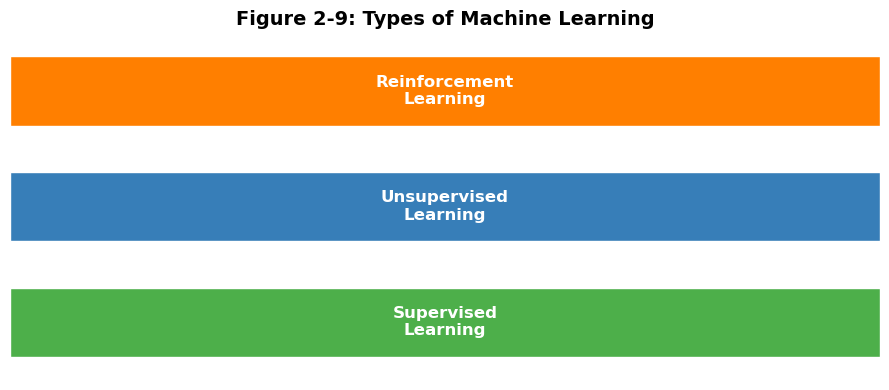

In [3]:
# Figure 2-9: Types of machine learning
fig, ax = plt.subplots(figsize=(9, 4))
categories = ['Supervised\nLearning', 'Unsupervised\nLearning', 'Reinforcement\nLearning']
colors = ['#4daf4a', '#377eb8', '#ff7f00']
y = [0.5, 0.5, 0.5]
ax.barh(categories, [1, 1, 1], color=colors, edgecolor='white', height=0.6)
for i, cat in enumerate(categories):
    ax.text(0.5, i, cat, ha='center', va='center', fontsize=12, fontweight='bold', color='white')
ax.set_xlim(0, 1)
ax.set_ylim(-0.5, 2.5)
ax.axis('off')
ax.set_title('Figure 2-9: Types of Machine Learning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Frameworks for Building ML Systems

Three widely used process frameworks:

### KDD — Knowledge Discovery in Databases (Figure 2-10)
Five stages: **Selection → Preprocessing → Transformation → Data Mining → Interpretation/Evaluation**

### CRISP-DM (Figure 2-11)
Six phases: **Business Understanding → Data Understanding → Data Preparation → Modeling → Evaluation → Deployment**

### SEMMA (SAS Enterprise Miner)
Five steps: **Sample → Explore → Modify → Model → Assess**

> The author recommends **CRISP-DM** for business environments because it covers the end-to-end lifecycle.


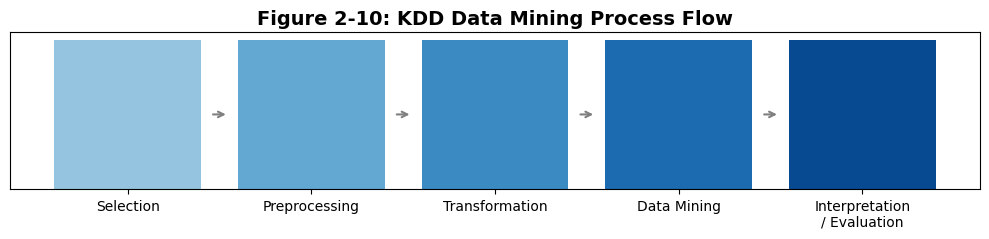

In [4]:
# Figure 2-10: KDD process flow
fig, ax = plt.subplots(figsize=(10, 2.5))
stages = ['Selection', 'Preprocessing', 'Transformation', 'Data Mining', 'Interpretation\n/ Evaluation']
x = np.arange(len(stages))
ax.bar(x, [1] * len(stages), color=plt.cm.Blues(np.linspace(0.4, 0.9, len(stages))))
ax.set_xticks(x)
ax.set_xticklabels(stages, fontsize=10)
ax.set_yticks([])
ax.set_title('Figure 2-10: KDD Data Mining Process Flow', fontsize=14, fontweight='bold')
for i in range(len(stages) - 1):
    ax.annotate('', xy=(i + 0.55, 0.5), xytext=(i + 0.45, 0.5),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
plt.tight_layout()
plt.show()


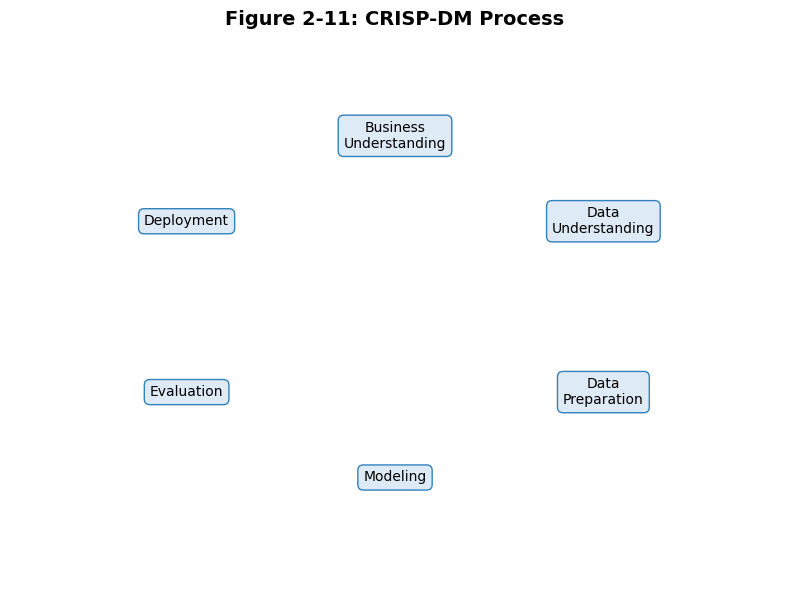

In [5]:
# Figure 2-11: CRISP-DM six phases
fig, ax = plt.subplots(figsize=(8, 6))
phases = [
    'Business\nUnderstanding', 'Data\nUnderstanding', 'Data\nPreparation',
    'Modeling', 'Evaluation', 'Deployment',
]
angles = np.linspace(90, 90 - 360, len(phases), endpoint=False)
radius = 2.5
for angle, phase in zip(angles, phases):
    rad = np.deg2rad(angle)
    cx, cy = radius * np.cos(rad), radius * np.sin(rad)
    ax.text(cx, cy, phase, ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#deebf7', edgecolor='#3182bd'))
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.axis('off')
ax.set_title('Figure 2-11: CRISP-DM Process', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Python Packages for Machine Learning

Scientific Python libraries divide into:
- **Data analysis:** NumPy, SciPy, Matplotlib, Pandas
- **Core ML:** scikit-learn, Keras, XGBoost, StatsModels, and others

This chapter focuses on **NumPy**, **Pandas**, and **Matplotlib**.

---

## NumPy

NumPy is the core library for scientific computing in Python. It provides high-performance **ndarray** objects and tools for working with them.

### Array Basics (Listing 2-1)

A NumPy array is a collection of values of the same type, indexed by non-negative integers. **Rank** = number of dimensions; **shape** = size along each dimension.


In [6]:
# Listing 2-1: Example Code for Initializing NumPy Array
# Create a rank 1 array
a = np.array([0, 1, 2])
print(type(a))
print(a.shape)
print(a[0])
print(a[1])
print(a[2])

# Change an element of the array
a[0] = 5
print(a)

# Create a rank 2 array
b = np.array([[0, 1, 2], [3, 4, 5]])
print(b.shape)
print(b)
print(b[0, 0], b[0, 1], b[1, 0])


<class 'numpy.ndarray'>
(3,)
0
1
2
[5 1 2]
(2, 3)
[[0 1 2]
 [3 4 5]]
0 1 3


### Creating NumPy Arrays (Listing 2-2)

NumPy provides many built-in functions to create arrays: `zeros`, `ones`, `full`, `random`, `eye`, `arange`, `linspace`, and `indices`.


In [7]:
# Listing 2-2: Creating NumPy Array
# Create a 3x3 array of all zeros
a = np.zeros((3, 3))
print(a)

# Create a 2x2 array of all ones
b = np.ones((2, 2))
print(b)

# Create a 3x3 constant array
c = np.full((3, 3), 7)
print(c)

# Create a 3x3 array filled with random values
d = np.random.random((3, 3))
print(d)

# Create a 3x3 identity matrix
e = np.eye(3)
print(e)

# convert list to array
f = np.array([2, 3, 1, 0])
print(f)

# arange() will create arrays with regularly incrementing values
g = np.arange(20)
print(g)

# note mix of tuple and lists
h = np.array([[0, 1, 2.0], [0, 0, 0], (1 + 1j, 3.0, 2.)])
print(h)

# create an array of range with float data type (np.float64 replaces deprecated np.float)
i = np.arange(1, 8, dtype=np.float64)
print(i)

# linspace() — equally spaced values between start and end
j = np.linspace(2.0, 4.0, 5)
print(j)

# indices() — grid of index arrays
k = np.indices((2, 2))
print(k)


[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
[[1. 1.]
 [1. 1.]]
[[7 7 7]
 [7 7 7]
 [7 7 7]]
[[0.08130979 0.09100085 0.76463089]
 [0.84319506 0.01519373 0.43981284]
 [0.93344826 0.16196738 0.14767133]]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
[2 3 1 0]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
[[0.+0.j 1.+0.j 2.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [1.+1.j 3.+0.j 2.+0.j]]
[1. 2. 3. 4. 5. 6. 7.]
[2.  2.5 3.  3.5 4. ]
[[[0 0]
  [1 1]]

 [[0 1]
  [0 1]]]


### NumPy Data Types (Listing 2-3)

Arrays hold items of the same type. Use the `dtype` argument to force a specific type.


In [8]:
# Listing 2-3: NumPy Data Types
# Let numpy choose the data type
x = np.array([0, 1])
y = np.array([2.0, 3.0])
# Force a particular data type
z = np.array([5, 6], dtype=np.int64)
print(x.dtype, y.dtype, z.dtype)


int32 float64 int64


### Field Access (Listing 2-4)

Structured arrays let you access named fields like a dictionary: `x['field-name']`.


In [9]:
# Listing 2-4: Field Access
x = np.zeros((3, 3), dtype=[('a', np.int32), ('b', np.float64, (3, 3))])
print("x['a'].shape: ", x['a'].shape)
print("x['a'].dtype: ", x['a'].dtype)
print("x['b'].shape: ", x['b'].shape)
print("x['b'].dtype: ", x['b'].dtype)


x['a'].shape:  (3, 3)
x['a'].dtype:  int32
x['b'].shape:  (3, 3, 3, 3)
x['b'].dtype:  float64


### Basic Slicing (Listings 2-5 through 2-10)

Slice syntax is `i:j:k` (start, stop, step). Slices are **views** — modifying a slice changes the original array.


In [10]:
# Listing 2-5: Basic Slicing
x = np.array([5, 6, 7, 8, 9])
print(x[1:7:2])


[6 8]


In [11]:
# Listing 2-6: Basic Slicing (continued)
x = np.array([5, 6, 7, 8, 9])
print(x[-2:5])
print(x[-1:1:-1])


[8 9]
[9 8 7]


In [12]:
# Listing 2-7: Basic Slicing (continued)
x = np.array([5, 6, 7, 8, 9])
print(x[4:])


[9]


In [13]:
# Listing 2-8: Basic Slicing (continued)
y = np.array([[[1], [2], [3]], [[4], [5], [6]]])
print("Shape of y: ", y.shape)
print(y[1:3])


Shape of y:  (2, 3, 1)
[[[4]
  [5]
  [6]]]


In [14]:
# Listing 2-9: Basic Slicing (continued)
x = np.array([5, 6, 7, 8, 9])
print(x[..., 0])

# Create a rank 2 array with shape (3, 4)
a = np.array([[5, 6, 7, 8], [1, 2, 3, 4], [9, 10, 11, 12]])
print("Array a:", a)
b = a[:2, 1:3]
print("Array b:", b)


5
Array a: [[ 5  6  7  8]
 [ 1  2  3  4]
 [ 9 10 11 12]]
Array b: [[6 7]
 [2 3]]


In [15]:
# Listing 2-10: Basic Slicing (continued)
a = np.array([[5, 6, 7, 8], [1, 2, 3, 4], [9, 10, 11, 12]])
print(a[0, 1])
b = a[:2, 1:3].copy()
b[0, 0] = 77
print("Original a[0,1] unchanged:", a[0, 1])
print("Modified b[0,0]:", b[0, 0])

# Rank 1 vs rank 2 row views
a = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
row_r1 = a[1, :]
row_r2 = a[1:2, :]
print(row_r1, row_r1.shape)
print(row_r2, row_r2.shape)

col_r1 = a[:, 1]
col_r2 = a[:, 1:2]
print(col_r1, col_r1.shape)
print(col_r2, col_r2.shape)


6
Original a[0,1] unchanged: 6
Modified b[0,0]: 77
[5 6 7 8] (4,)
[[5 6 7 8]] (1, 4)
[ 2  6 10] (3,)
[[ 2]
 [ 6]
 [10]] (3, 1)


### Advanced Indexing (Listings 2-11 and 2-12)

**Integer array indexing** picks elements by index arrays. **Boolean indexing** filters elements that satisfy a condition.


In [16]:
# Listing 2-11: Advanced Indexing
a = np.array([[1, 2], [3, 4]])
print(a[[0, 1], [0, 1]])
print(np.array([a[0, 0], a[1, 1]]))
print(a[[0, 0], [1, 1]])
print(np.array([a[0, 1], a[0, 1]]))


[1 4]
[1 4]
[2 2]
[2 2]


In [17]:
# Listing 2-12: Boolean Array Indexing
a = np.array([[1, 2], [3, 4], [5, 6]])
print(a > 2)
print(a[a > 2])


[[False False]
 [ True  True]
 [ True  True]]
[3 4 5 6]


### Array Math (Listings 2-13 and 2-14)

NumPy supports elementwise `+`, `-`, `*`, `/` and functions like `np.add`, `np.sqrt`, and `np.dot` for matrix operations.


In [18]:
# Listing 2-13: Array Math
x = np.array([[1, 2], [3, 4], [5, 6]])
y = np.array([[7, 8], [9, 10], [11, 12]])
print(x + y)
print(np.add(x, y))
print(x - y)
print(np.subtract(x, y))
print(x * y)
print(np.multiply(x, y))
print(x / y)
print(np.divide(x, y))
print(np.sqrt(x))


[[ 8 10]
 [12 14]
 [16 18]]
[[ 8 10]
 [12 14]
 [16 18]]
[[-6 -6]
 [-6 -6]
 [-6 -6]]
[[-6 -6]
 [-6 -6]
 [-6 -6]]
[[ 7 16]
 [27 40]
 [55 72]]
[[ 7 16]
 [27 40]
 [55 72]]
[[0.14285714 0.25      ]
 [0.33333333 0.4       ]
 [0.45454545 0.5       ]]
[[0.14285714 0.25      ]
 [0.33333333 0.4       ]
 [0.45454545 0.5       ]]
[[1.         1.41421356]
 [1.73205081 2.        ]
 [2.23606798 2.44948974]]


In [19]:
# Listing 2-14: Array Math (continued)
x = np.array([[1, 2], [3, 4]])
y = np.array([[5, 6], [7, 8]])
a = np.array([9, 10])
b = np.array([11, 12])
print(a.dot(b))
print(np.dot(a, b))
print(x.dot(a))
print(np.dot(x, a))
print(x.dot(y))
print(np.dot(x, y))


219
219
[29 67]
[29 67]
[[19 22]
 [43 50]]
[[19 22]
 [43 50]]


### Sum and Transpose (Listings 2-15 and 2-16)


In [20]:
# Listing 2-15: Sum Function
x = np.array([[1, 2], [3, 4]])
print(np.sum(x))
print(np.sum(x, axis=0))
print(np.sum(x, axis=1))


10
[4 6]
[3 7]


In [21]:
# Listing 2-16: Transpose Function
x = np.array([[1, 2], [3, 4]])
print(x)
print(x.T)
v = np.array([1, 2, 3])
print(v)
print(v.T)


[[1 2]
 [3 4]]
[[1 3]
 [2 4]]
[1 2 3]
[1 2 3]


### Broadcasting (Listings 2-17 through 2-20)

**Broadcasting** lets NumPy perform arithmetic between arrays of different shapes without explicit loops — making code faster and more concise.


In [22]:
# Listing 2-17: Broadcasting
a = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
v = np.array([1, 0, 1])
b = np.empty_like(a)
for i in range(3):
    b[i, :] = a[i, :] + v
print(b)


[[ 2  2  4]
 [ 5  5  7]
 [ 8  8 10]]


In [23]:
# Listing 2-18: Broadcasting for Large Matrix
a = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
v = np.array([1, 0, 1])
vv = np.tile(v, (3, 1))
print(vv)
b = a + vv
print(b)


[[1 0 1]
 [1 0 1]
 [1 0 1]]
[[ 2  2  4]
 [ 5  5  7]
 [ 8  8 10]]


In [24]:
# Listing 2-19: Broadcasting Using NumPy
a = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
v = np.array([1, 0, 1])
b = a + v
print(b)


[[ 2  2  4]
 [ 5  5  7]
 [ 8  8 10]]


In [25]:
# Listing 2-20: Applications of Broadcasting
v = np.array([1, 2, 3])
w = np.array([4, 5])
print(np.reshape(v, (3, 1)) * w)

x = np.array([[1, 2, 3], [4, 5, 6]])
print(x + v)
print((x.T + w).T)
print(x + np.reshape(w, (2, 1)))
print(x * 2)


[[ 4  5]
 [ 8 10]
 [12 15]]
[[2 4 6]
 [5 7 9]]
[[ 5  6  7]
 [ 9 10 11]]
[[ 5  6  7]
 [ 9 10 11]]
[[ 2  4  6]
 [ 8 10 12]]


---

## Pandas

Pandas provides fast, flexible data structures for **labeled tabular data** — like spreadsheets or SQL tables. It builds on top of NumPy.

### Series (Listing 2-21)

A **Series** is a one-dimensional labeled array (like a spreadsheet column).


In [26]:
# Listing 2-21: Creating a Pandas Series
s = pd.Series([1, 2, 3, np.nan, 5, 6], index=['A', 'B', 'C', 'D', 'E', 'F'])
print(s)


A    1.0
B    2.0
C    3.0
D    NaN
E    5.0
F    6.0
dtype: float64


### DataFrame (Listing 2-22)

A **DataFrame** is a two-dimensional table — the most commonly used Pandas object.


In [27]:
# Listing 2-22: Creating a Pandas DataFrame
data = {'Gender': ['F', 'M', 'M'],
        'Emp_ID': ['E01', 'E02', 'E03'],
        'Age': [25, 27, 25]}
df = pd.DataFrame(data, columns=['Emp_ID', 'Gender', 'Age'])
df


,Emp_ID,Gender,Age
0,E01,F,25
1,E02,M,27
2,E03,M,25


### Reading and Writing Data (Listing 2-23)

Pandas reads/writes CSV, text, and Excel files. This listing uses **temporary files** in the notebook directory instead of bundled `Data/` files.


In [28]:
# Listing 2-23: Reading/Writing Data from csv, text, Excel
sample_df = iris_df.head(10)
csv_path = NOTEBOOK_DIR / '_temp_mtcars.csv'
txt_path = NOTEBOOK_DIR / '_temp_mtcars.txt'
xlsx_path = NOTEBOOK_DIR / '_temp_mtcars.xlsx'

# Writing
sample_df.to_csv(csv_path, index=False)
sample_df.to_csv(txt_path, sep='\t', index=False)

# Reading
df = pd.read_csv(csv_path)
print('From CSV:')
print(df.head(3))

df = pd.read_csv(txt_path, sep='\t')
print('\nFrom text file:')
print(df.head(3))

# Excel (requires openpyxl)
try:
    sample_df.to_excel(xlsx_path, sheet_name='Sheet1', index=False)
    df = pd.read_excel(xlsx_path, 'Sheet1')
    print('\nFrom Excel:')
    print(df.head(3))
except ImportError:
    print('\nInstall openpyxl for Excel support: pip install openpyxl')

# Write copies (index=False omits row index)
sample_df.to_csv(NOTEBOOK_DIR / '_temp_mtcars_new.csv', index=False)
sample_df.to_csv(NOTEBOOK_DIR / '_temp_mtcars_new.txt', sep='\t', index=False)


From CSV:
   Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2



From text file:
   Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2



From Excel:
   Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2


### Basic Statistics (Listings 2-24 through 2-26)

Use `describe()`, `cov()`, and `corr()` to summarize Iris data.


In [29]:
# Listing 2-24: Basic Statistics on DataFrame
df = iris_df
df.describe()


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [30]:
# Listing 2-25: Creating Covariance on DataFrame
df = iris_df
df.cov()


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Sepal.Length,0.685694,-0.042434,1.274315,0.516271
Sepal.Width,-0.042434,0.189979,-0.329656,-0.121639
Petal.Length,1.274315,-0.329656,3.116278,1.295609
Petal.Width,0.516271,-0.121639,1.295609,0.581006


In [31]:
# Listing 2-26: Creating Correlation Matrix on DataFrame
df = iris_df
df.corr()


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Sepal.Length,1.000000,-0.117570,0.871754,0.817941
Sepal.Width,-0.117570,1.000000,-0.428440,-0.366126
Petal.Length,0.871754,-0.428440,1.000000,0.962865
Petal.Width,0.817941,-0.366126,0.962865,1.000000


### Merge and Join (Listings 2-27 through 2-32)

`pd.concat` stacks DataFrames. `pd.merge` performs SQL-style joins on a common column. We use `df_1` and `df_2` from the setup cell.


In [32]:
# Listing 2-27: Concat Operation
# Using concat (replaces deprecated DataFrame.append)
df = pd.concat([df_1, df_2], ignore_index=True)
print(df)
print('\nConcat along columns:')
print(pd.concat([df_1, df_2], axis=1))


  emp_id first_name  last_name
0      1      Jason     Larkin
1      2       Andy      Jacob
2      3      Allen          A
3      4      Alice         AA
4      5        Amy    Jackson
5      4      Brian  Alexander
6      5      Shize       Suma
7      6        Kim       Mike
8      7       Jose          G

Concat along columns:
  emp_id first_name last_name emp_id first_name  last_name
0      1      Jason    Larkin      4      Brian  Alexander
1      2       Andy     Jacob      5      Shize       Suma
2      3      Allen         A      6        Kim       Mike
3      4      Alice        AA      7       Jose          G
4      5        Amy   Jackson    NaN        NaN        NaN


In [33]:
# Listing 2-28: Merge Two DataFrames
pd.merge(df_1, df_2, on='emp_id')


,emp_id,first_name_x,last_name_x,first_name_y,last_name_y
0,4,Alice,AA,Brian,Alexander
1,5,Amy,Jackson,Shize,Suma


In [34]:
# Listing 2-29: Left Join Two DataFrames
print(pd.merge(df_1, df_2, on='emp_id', how='left'))
print('\nWith suffixes:')
print(pd.merge(df_1, df_2, on='emp_id', how='left', suffixes=('_left', '_right')))


  emp_id first_name_x last_name_x first_name_y last_name_y
0      1        Jason      Larkin          NaN         NaN
1      2         Andy       Jacob          NaN         NaN
2      3        Allen           A          NaN         NaN
3      4        Alice          AA        Brian   Alexander
4      5          Amy     Jackson        Shize        Suma

With suffixes:
  emp_id first_name_left last_name_left first_name_right last_name_right
0      1           Jason         Larkin              NaN             NaN
1      2            Andy          Jacob              NaN             NaN
2      3           Allen              A              NaN             NaN
3      4           Alice             AA            Brian       Alexander
4      5             Amy        Jackson            Shize            Suma


In [35]:
# Listing 2-30: Right Join Two DataFrames
pd.merge(df_1, df_2, on='emp_id', how='right')


,emp_id,first_name_x,last_name_x,first_name_y,last_name_y
0,4,Alice,AA,Brian,Alexander
1,5,Amy,Jackson,Shize,Suma
2,6,NaN,NaN,Kim,Mike
3,7,NaN,NaN,Jose,G


In [36]:
# Listing 2-31: Inner Join Two DataFrames
pd.merge(df_1, df_2, on='emp_id', how='inner')


,emp_id,first_name_x,last_name_x,first_name_y,last_name_y
0,4,Alice,AA,Brian,Alexander
1,5,Amy,Jackson,Shize,Suma


In [37]:
# Listing 2-32: Outer Join Two DataFrames
pd.merge(df_1, df_2, on='emp_id', how='outer')


,emp_id,first_name_x,last_name_x,first_name_y,last_name_y
0,1,Jason,Larkin,NaN,NaN
1,2,Andy,Jacob,NaN,NaN
2,3,Allen,A,NaN,NaN
3,4,Alice,AA,Brian,Alexander
4,5,Amy,Jackson,Shize,Suma
5,6,NaN,NaN,Kim,Mike
6,7,NaN,NaN,Jose,G


### Grouping and Pivot Tables (Listings 2-33 and 2-34)

**GroupBy** splits data, applies a function per group, and combines results. **Pivot tables** aggregate like Excel.


In [38]:
# Listing 2-33: Grouping Operation
np.random.seed(42)
df = pd.DataFrame({
    'Name': ['jack', 'jane', 'jack', 'jane', 'jack', 'jane', 'jack', 'jane'],
    'State': ['SFO', 'SFO', 'NYK', 'CA', 'NYK', 'NYK', 'SFO', 'CA'],
    'Grade': ['A', 'A', 'B', 'A', 'C', 'B', 'C', 'A'],
    'Age': np.random.uniform(24, 50, size=8),
    'Salary': np.random.uniform(3000, 5000, size=8),
})
df.groupby(['Name', 'State']).max()


Grade        Age       Salary
Name State                              
jack NYK       C  43.031842  4664.885282
     SFO       C  33.738043  4202.230023
jane CA        A  46.520580  4939.819704
     NYK       B  28.055858  3424.678221
     SFO       A  48.718572  4416.145156

In [39]:
# Listing 2-34: Pivot Tables
np.random.seed(42)
df = pd.DataFrame({
    'Name': ['jack', 'jane', 'jack', 'jane', 'jack', 'jane', 'jack', 'jane'],
    'State': ['SFO', 'SFO', 'NYK', 'CA', 'NYK', 'NYK', 'SFO', 'CA'],
    'Grade': ['A', 'A', 'B', 'A', 'C', 'B', 'C', 'A'],
    'Age': np.random.uniform(24, 50, size=8),
    'Salary': np.random.uniform(3000, 5000, size=8),
})
pd.pivot_table(df, values='Age', index=['State', 'Name'], columns=['Grade'])


Grade               A          B          C
State Name                                 
CA    jane  43.042850        NaN        NaN
NYK   jack        NaN  43.031842  28.056485
      jane        NaN  28.055858        NaN
SFO   jack  33.738043        NaN  25.510174
      jane  48.718572        NaN        NaN

---

## Matplotlib

Matplotlib visualizes data graphically. Two approaches:
- **Global functions** (`plt.plot`, `plt.bar`) — quick and MATLAB-like
- **Object-oriented** (`fig, ax = plt.subplots()`) — more control

The first plotting cell below sets `%matplotlib inline` so charts appear in the notebook.


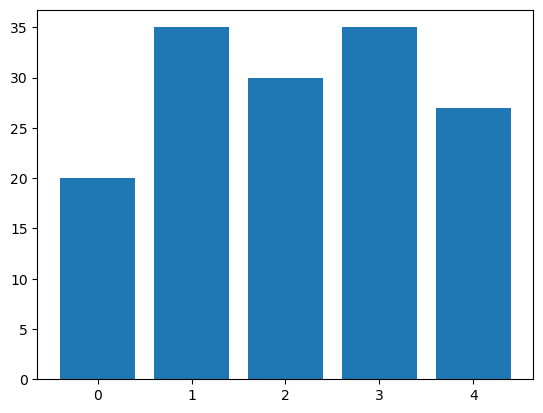

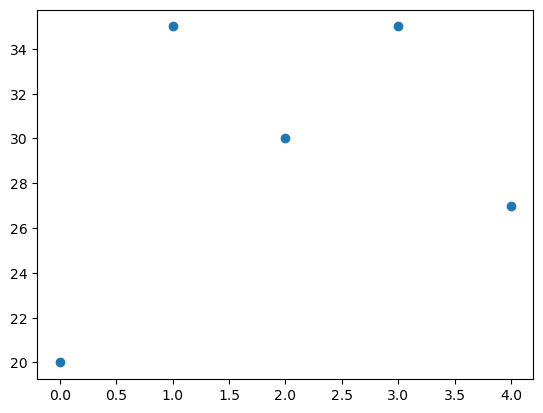

In [40]:
# Listing 2-35: Creating a Plot on Variables
%matplotlib inline

x = np.arange(5)
y = (20, 35, 30, 35, 27)
plt.bar(x, y)
plt.show()
plt.scatter(x, y)
plt.show()


### Plots Directly on DataFrames (Listing 2-36)


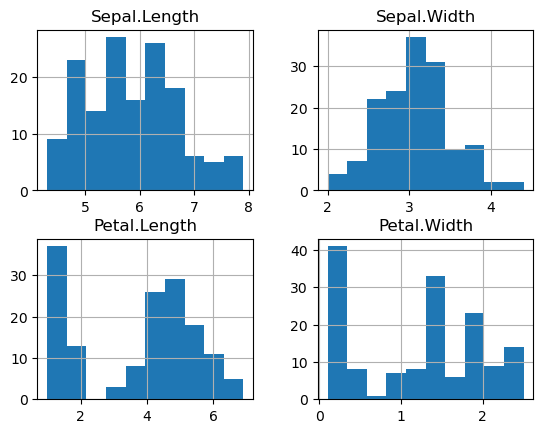

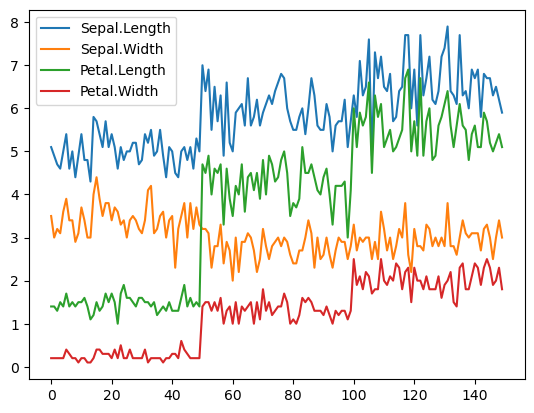

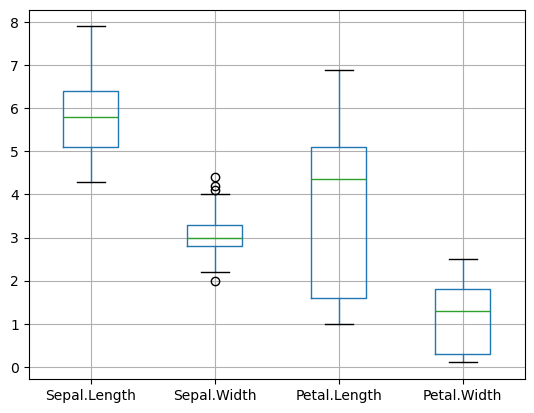

In [41]:
# Listing 2-36: Creating Plot on DataFrame
df = iris_df
df.hist()
plt.show()
df.plot()
plt.show()
df.boxplot()
plt.show()


### Customizing Labels (Listing 2-37)


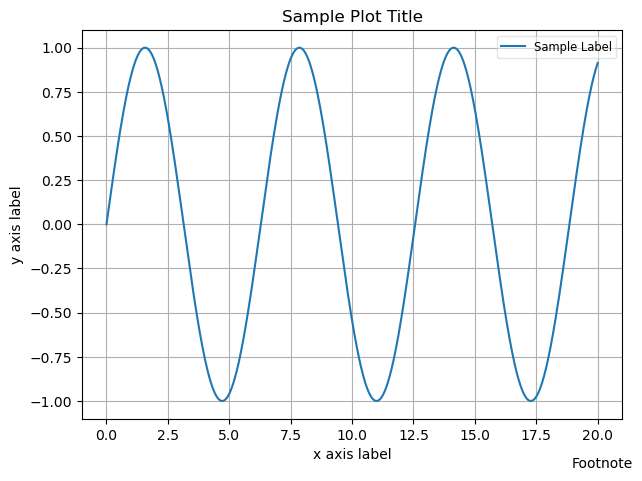

In [42]:
# Listing 2-37: Customize Labels
x = np.linspace(0, 20, 1000)
y = np.sin(x)
plt.plot(x, y, label='Sample Label')
plt.title('Sample Plot Title')
plt.xlabel('x axis label')
plt.ylabel('y axis label')
plt.grid(True)
plt.figtext(0.995, 0.01, 'Footnote', ha='right', va='bottom')
plt.legend(loc='best', framealpha=0.5, prop={'size': 'small'})
plt.tight_layout(pad=1)
plt.show()


### Object-Oriented API (Listing 2-38)

A **Figure** is the top-level container; **Axes** hold individual plots.


In [43]:
# Listing 2-38: Object-Oriented Customization
fig, ax = plt.subplots()
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(8, 4))
for ax_i in fig.get_axes():
    pass  # iterate over axes
plt.close('all')
print('Object-oriented subplot setup demonstrated.')


Object-oriented subplot setup demonstrated.


### Line Plots (Listings 2-39 through 2-42)


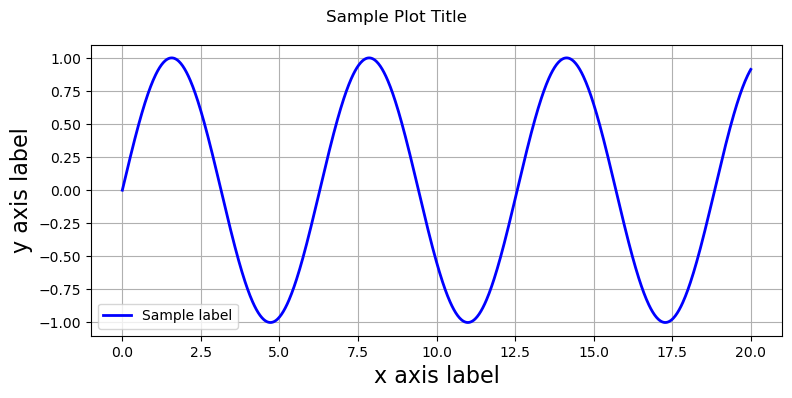

In [44]:
# Listing 2-39: Single Line Plot Using ax.plot()
x = np.linspace(0, 20, 1000)
y = np.sin(x)
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(1, 1, 1)
ax.plot(x, y, 'b-', linewidth=2, label='Sample label')
ax.set_ylabel('y axis label', fontsize=16)
ax.set_xlabel('x axis label', fontsize=16)
ax.legend(loc='best')
ax.grid(True)
fig.suptitle('Sample Plot Title')
fig.tight_layout(pad=1)
plt.show()


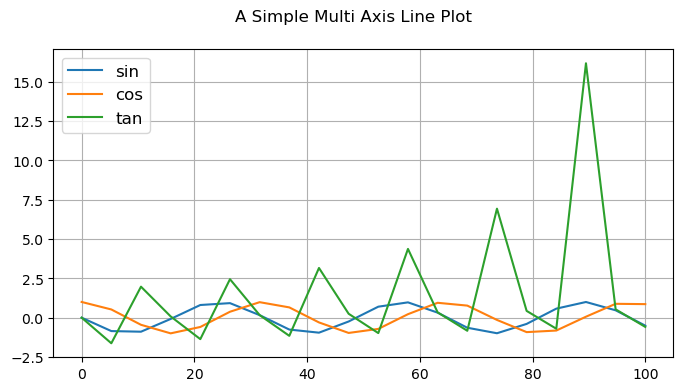

In [45]:
# Listing 2-40: Multiple Line Plot on the Same Axis
fig, ax = plt.subplots(figsize=(8, 4))
x1 = np.linspace(0, 100, 20)
x2 = np.linspace(0, 100, 20)
x3 = np.linspace(0, 100, 20)
y1 = np.sin(x1)
y2 = np.cos(x2)
y3 = np.tan(x3)
ax.plot(x1, y1, label='sin')
ax.plot(x2, y2, label='cos')
ax.plot(x3, y3, label='tan')
ax.grid(True)
ax.legend(loc='best', prop={'size': 'large'})
fig.suptitle('A Simple Multi Axis Line Plot')
plt.show()


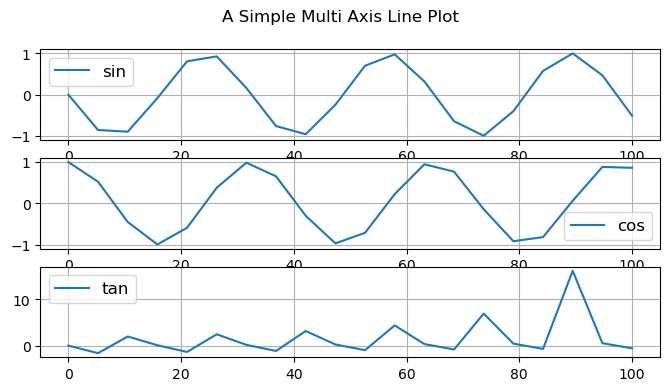

In [46]:
# Listing 2-41: Multiple Lines on Different Axes
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, sharex=False, sharey=False, figsize=(8, 4))
x1 = np.linspace(0, 100, 20)
x2 = np.linspace(0, 100, 20)
x3 = np.linspace(0, 100, 20)
y1 = np.sin(x1)
y2 = np.cos(x2)
y3 = np.tan(x3)
ax1.plot(x1, y1, label='sin')
ax2.plot(x2, y2, label='cos')
ax3.plot(x3, y3, label='tan')
ax1.grid(True)
ax2.grid(True)
ax3.grid(True)
ax1.legend(loc='best', prop={'size': 'large'})
ax2.legend(loc='best', prop={'size': 'large'})
ax3.legend(loc='best', prop={'size': 'large'})
fig.suptitle('A Simple Multi Axis Line Plot')
plt.show()


### Line and Marker Styles (Listing 2-42)

Figure 2-14 (line styles) and Figure 2-15 (markers) are generated in the next cells.


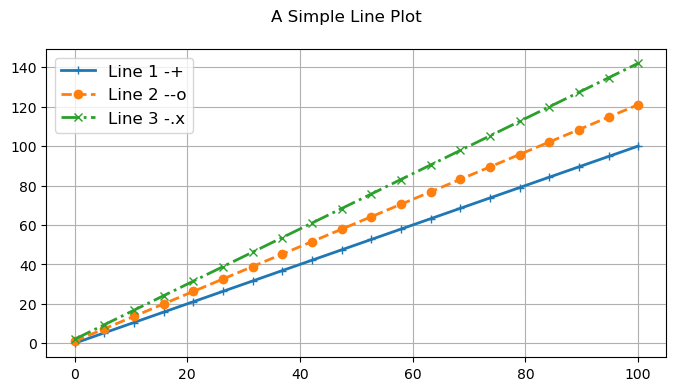

In [47]:
# Listing 2-42: Line Style and Marker Style Controls
fig, ax = plt.subplots(figsize=(8, 4))
N = 3
styles = ['-', '--', '-.', ':']
markers = list('+ox')
x = np.linspace(0, 100, 20)
for i in range(N):
    y = x + x / 5 * i + i
    s = styles[i % len(styles)]
    m = markers[i % len(markers)]
    ax.plot(x, y, alpha=1, label='Line ' + str(i + 1) + ' ' + s + m,
            marker=m, linewidth=2, linestyle=s)
ax.grid(True)
ax.legend(loc='best', prop={'size': 'large'})
fig.suptitle('A Simple Line Plot')
plt.show()


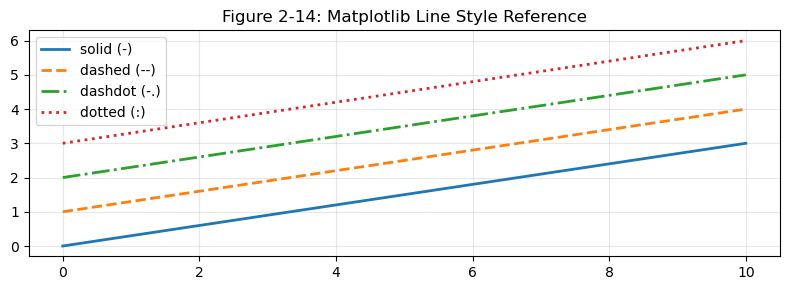

In [48]:
# Figure 2-14: Matplotlib line style reference
fig, ax = plt.subplots(figsize=(8, 3))
styles = ['-', '--', '-.', ':']
labels = ['solid (-)', 'dashed (--)', 'dashdot (-.)', 'dotted (:)']
x = np.linspace(0, 10, 50)
for i, (s, lbl) in enumerate(zip(styles, labels)):
    ax.plot(x, x * 0.3 + i, linestyle=s, linewidth=2, label=lbl)
ax.legend(loc='best')
ax.set_title('Figure 2-14: Matplotlib Line Style Reference')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


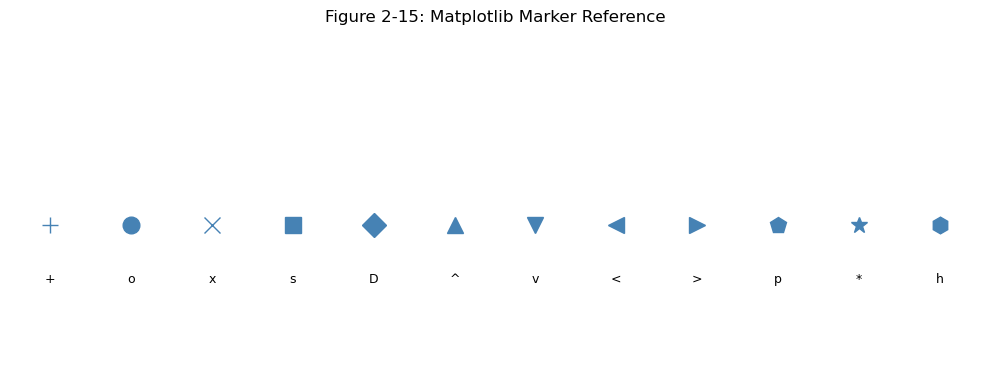

In [49]:
# Figure 2-15: Matplotlib marker reference
fig, ax = plt.subplots(figsize=(10, 4))
markers = ['+', 'o', 'x', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h']
x = np.arange(len(markers))
for i, m in enumerate(markers):
    ax.plot(i, 0, marker=m, markersize=12, linestyle='None', color='steelblue')
    ax.text(i, -0.15, m, ha='center', fontsize=9)
ax.set_xlim(-0.5, len(markers) - 0.5)
ax.set_ylim(-0.4, 0.5)
ax.axis('off')
ax.set_title('Figure 2-15: Matplotlib Marker Reference')
plt.tight_layout()
plt.show()


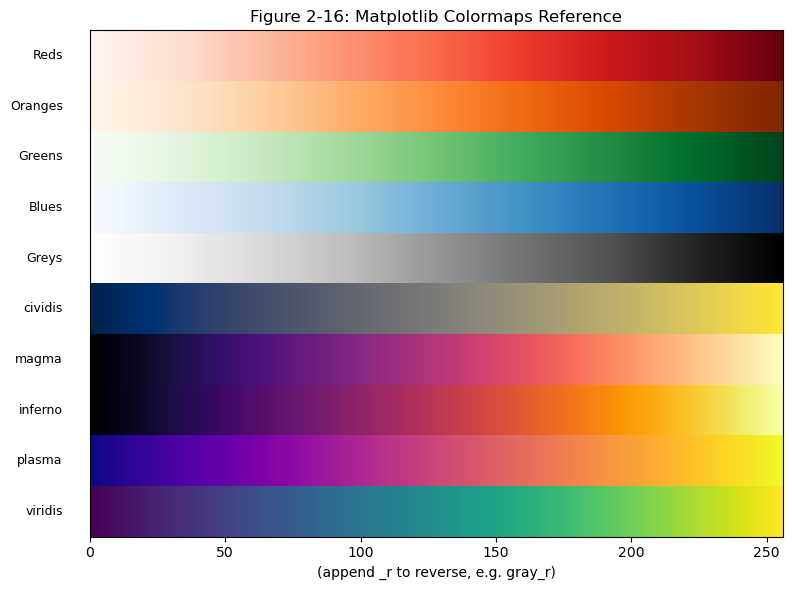

In [50]:
# Figure 2-16: Matplotlib colormaps reference
fig, ax = plt.subplots(figsize=(8, 6))
cmaps = ['viridis', 'plasma', 'inferno', 'magma', 'cividis',
         'Greys', 'Blues', 'Greens', 'Oranges', 'Reds']
gradient = np.linspace(0, 1, 256).reshape(1, -1)
for i, cmap in enumerate(cmaps):
    ax.imshow(gradient, aspect='auto', cmap=cmap,
              extent=[0, 256, i, i + 1])
    ax.text(-10, i + 0.5, cmap, va='center', ha='right', fontsize=9)
ax.set_xlim(0, 256)
ax.set_ylim(0, len(cmaps))
ax.set_title('Figure 2-16: Matplotlib Colormaps Reference')
ax.set_yticks([])
ax.set_xlabel('(append _r to reverse, e.g. gray_r)')
plt.tight_layout()
plt.show()


### Bar Charts (Listings 2-43 through 2-46)


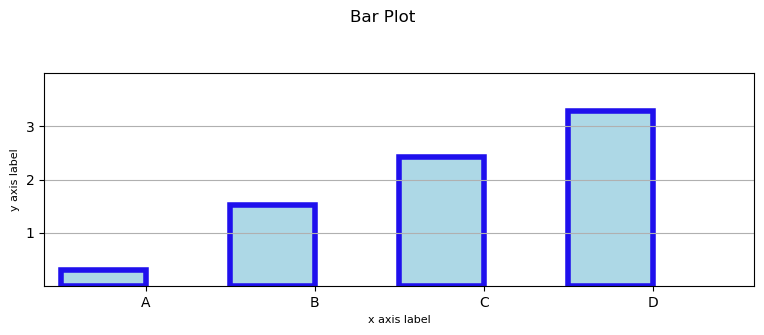

In [51]:
# Listing 2-43: Bar Plots Using ax.bar() and ax.barh()
N = 4
labels = list('ABCD')
data = np.array(range(N)) + np.random.rand(N)
fig, ax = plt.subplots(figsize=(8, 3.5))
width = 0.5
tickLocations = np.arange(N)
rectLocations = tickLocations - (width / 2.0)
ax.bar(rectLocations, data, width,
       color='lightblue', edgecolor='#1f10ed', linewidth=4.0)
ax.set_xticks(ticks=tickLocations)
ax.set_xticklabels(labels)
ax.set_xlim(min(tickLocations) - 0.6, max(tickLocations) + 0.6)
ax.set_yticks(range(N)[1:])
ax.set_ylim((0, N))
ax.yaxis.grid(True)
ax.set_ylabel('y axis label', fontsize=8)
ax.set_xlabel('x axis label', fontsize=8)
fig.suptitle('Bar Plot')
fig.tight_layout(pad=2)
plt.show()


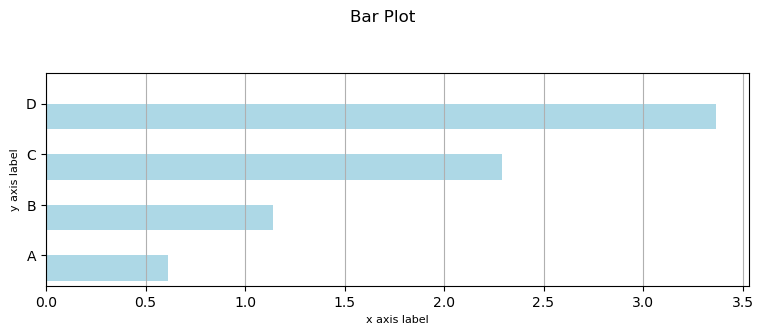

In [52]:
# Listing 2-44: Horizontal Bar Charts
N = 4
labels = list('ABCD')
data = np.array(range(N)) + np.random.rand(N)
fig, ax = plt.subplots(figsize=(8, 3.5))
width = 0.5
tickLocations = np.arange(N)
rectLocations = tickLocations - (width / 2.0)
ax.barh(rectLocations, data, width, color='lightblue')
ax.set_yticks(ticks=tickLocations)
ax.set_yticklabels(labels)
ax.set_ylim(min(tickLocations) - 0.6, max(tickLocations) + 0.6)
ax.xaxis.grid(True)
ax.set_ylabel('y axis label', fontsize=8)
ax.set_xlabel('x axis label', fontsize=8)
fig.suptitle('Bar Plot')
fig.tight_layout(pad=2)
plt.show()


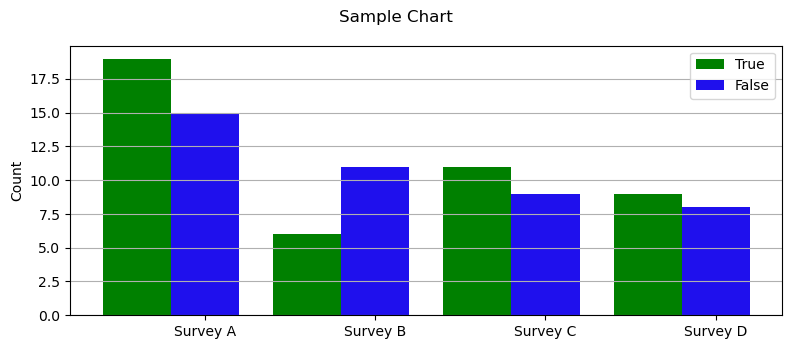

In [53]:
# Listing 2-45: Side by Side Bar Chart
pre = np.array([19, 6, 11, 9])
post = np.array([15, 11, 9, 8])
labels = ['Survey ' + x for x in list('ABCD')]
fig, ax = plt.subplots(figsize=(8, 3.5))
width = 0.4
xlocs = np.arange(len(pre))
ax.bar(xlocs - width, pre, width, color='green', label='True')
ax.bar(xlocs, post, width, color='#1f10ed', label='False')
ax.set_xticks(ticks=range(len(pre)))
ax.set_xticklabels(labels)
ax.yaxis.grid(True)
ax.legend(loc='best')
ax.set_ylabel('Count')
fig.suptitle('Sample Chart')
fig.tight_layout(pad=1)
plt.show()


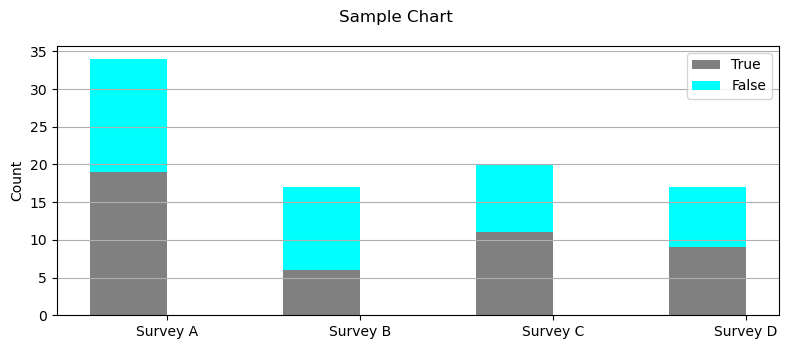

In [54]:
# Listing 2-46: Stacked Bar Charts
pre = np.array([19, 6, 11, 9])
post = np.array([15, 11, 9, 8])
labels = ['Survey ' + x for x in list('ABCD')]
fig, ax = plt.subplots(figsize=(8, 3.5))
width = 0.4
xlocs = np.arange(len(pre) + 2)
adjlocs = xlocs[1:-1] - width / 2.0
ax.bar(adjlocs, pre, width, color='grey', label='True')
ax.bar(adjlocs, post, width, color='cyan', label='False', bottom=pre)
ax.set_xticks(ticks=xlocs[1:-1])
ax.set_xticklabels(labels)
ax.yaxis.grid(True)
ax.legend(loc='best')
ax.set_ylabel('Count')
fig.suptitle('Sample Chart')
fig.tight_layout(pad=1)
plt.show()


### Pie Chart and Grid Layout (Listings 2-47 and 2-48)


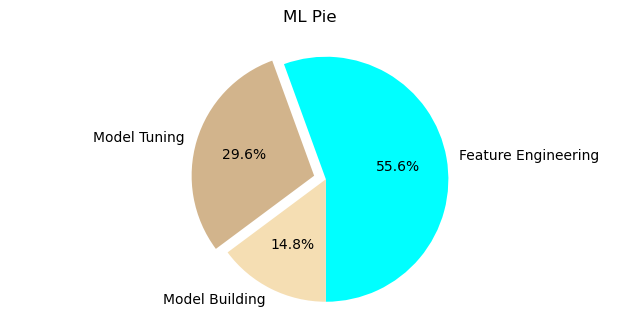

In [55]:
# Listing 2-47: Pie Chart
data = np.array([15, 8, 4])
labels = ['Feature Engineering', 'Model Tuning', 'Model Building']
explode = (0, 0.1, 0)
colrs = ['cyan', 'tan', 'wheat']
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.pie(data, explode=explode, labels=labels, autopct='%1.1f%%',
       startangle=270, colors=colrs)
ax.axis('equal')
fig.suptitle('ML Pie')
plt.show()


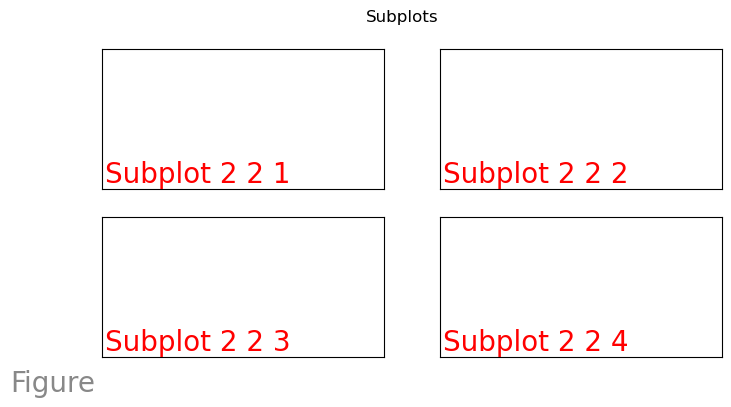

In [56]:
# Listing 2-48: Grid Creation
fig = plt.figure(figsize=(8, 4))
fig.text(x=0.01, y=0.01, s='Figure', color='#888888', ha='left',
         va='bottom', fontsize=20)
for i in range(4):
    ax = fig.add_subplot(2, 2, i + 1)
    ax.text(x=0.01, y=0.01, s='Subplot 2 2 ' + str(i + 1), color='red',
            ha='left', va='bottom', fontsize=20)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle('Subplots')
plt.show()


### Plotting Defaults (Listing 2-49)

Matplotlib settings live in `matplotlibrc`. Use `plt.rc()` to change defaults for figures, axes, grids, and legends.


C:\ProgramData\anaconda3\Lib\site-packages\matplotlib\mpl-data\matplotlibrc
rcParams keys (sample): ['_internal.classic_mode', 'agg.path.chunksize', 'animation.bitrate', 'animation.codec', 'animation.convert_args', 'animation.convert_path', 'animation.embed_limit', 'animation.ffmpeg_args'] ...


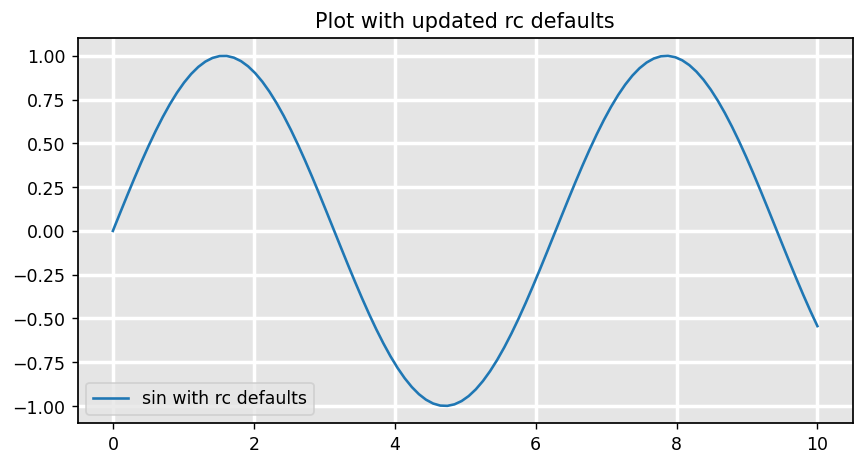

In [57]:
# Listing 2-49: Plotting Defaults
print(matplotlib.matplotlib_fname())
print('rcParams keys (sample):', list(matplotlib.rcParams.keys())[:8], '...')

plt.rc('figure', figsize=(8, 4), dpi=125, facecolor='white', edgecolor='white')
plt.rc('axes', facecolor='#e5e5e5', grid=True, linewidth=1.0, axisbelow=True)
plt.rc('grid', color='white', linestyle='-', linewidth=2.0, alpha=1.0)
plt.rc('xtick', direction='out')
plt.rc('ytick', direction='out')
plt.rc('legend', loc='best')

x = np.linspace(0, 10, 100)
fig, ax = plt.subplots()
ax.plot(x, np.sin(x), label='sin with rc defaults')
ax.legend()
ax.set_title('Plot with updated rc defaults')
plt.show()


---

## Machine Learning Core Libraries (scikit-learn Summary)

**scikit-learn** (sklearn) is the most popular Python ML library — built on SciPy with a rich set of supervised and unsupervised algorithms.

| Library | Description |
|---|---|
| **scikit-learn** | General-purpose ML: classification, regression, clustering |
| **Keras** | Deep learning API |
| **XGBoost** | Gradient boosting |
| **StatsModels** | Statistical models and regression diagnostics |

We explore scikit-learn algorithms in detail in **Chapter 3**.

---

## Summary

In this chapter you learned:
- What **machine learning** is and where it fits in the **AI** family
- Related fields: statistics, data mining, analytics, and data science
- ML categories: **supervised**, **unsupervised**, and **reinforcement** learning
- Process frameworks: **KDD**, **CRISP-DM**, and **SEMMA**
- Core Python data libraries: **NumPy**, **Pandas**, and **Matplotlib**
- All **49 code listings** from the textbook with modern Python 3 fixes

## Additional Resources (Table 2-5)

| Resource | Description | Mode |
|---|---|---|
| [NumPy Reference](https://docs.scipy.org/doc/numpy/reference/) | Official NumPy quick start and reference | Online |
| [Pandas Tutorials](https://pandas.pydata.org/pandas-docs/stable/tutorials.html) | Guided tutorials for new Pandas users | Online |
| [Matplotlib Beginner's Guide](https://matplotlib.org/stable/users/beginner.html) | pyplot tutorial and getting started | Online |
| *Python for Data Analysis* — Wes McKinney | Data manipulation and analysis in Python | Book |

---

**Next:** Chapter 3 — Fundamentals of Machine Learning with scikit-learn.
